# Configuration

In [1]:
import os 
import pickle

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

from scipy.special import expit
from sklearn.linear_model import LogisticRegression, Lasso 

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, Targeting
from core.targeting import *
from core.variables import *

# DGP

In [5]:
dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.1) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# dgp_params = {
#     'base_effects': [PointMass(0.1), PointMass(0.11)], 
#     'cust_feat_var': Uniform(0, 1), 
#     'char_func': lambda x: x**2 + x, 
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# instantiate the DGP
dgp = Targeting(**dgp_params)

In [6]:
# sample 
cust_features, treatments, outcomes = dgp.sample(1000)
oos_cust_features = dgp.sample_individuals(1000)

# Estimation

In [7]:
cfdml = CausalForestDML(
    n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
    n_estimators=100, max_depth=5, n_jobs=-1, discrete_treatment=True
).fit(X=cust_features, Y=outcomes, T=treatments)

emp_targ_te_arr, emp_targ_var_arr = cfdml.predict_incremental_effect(oos_cust_features)

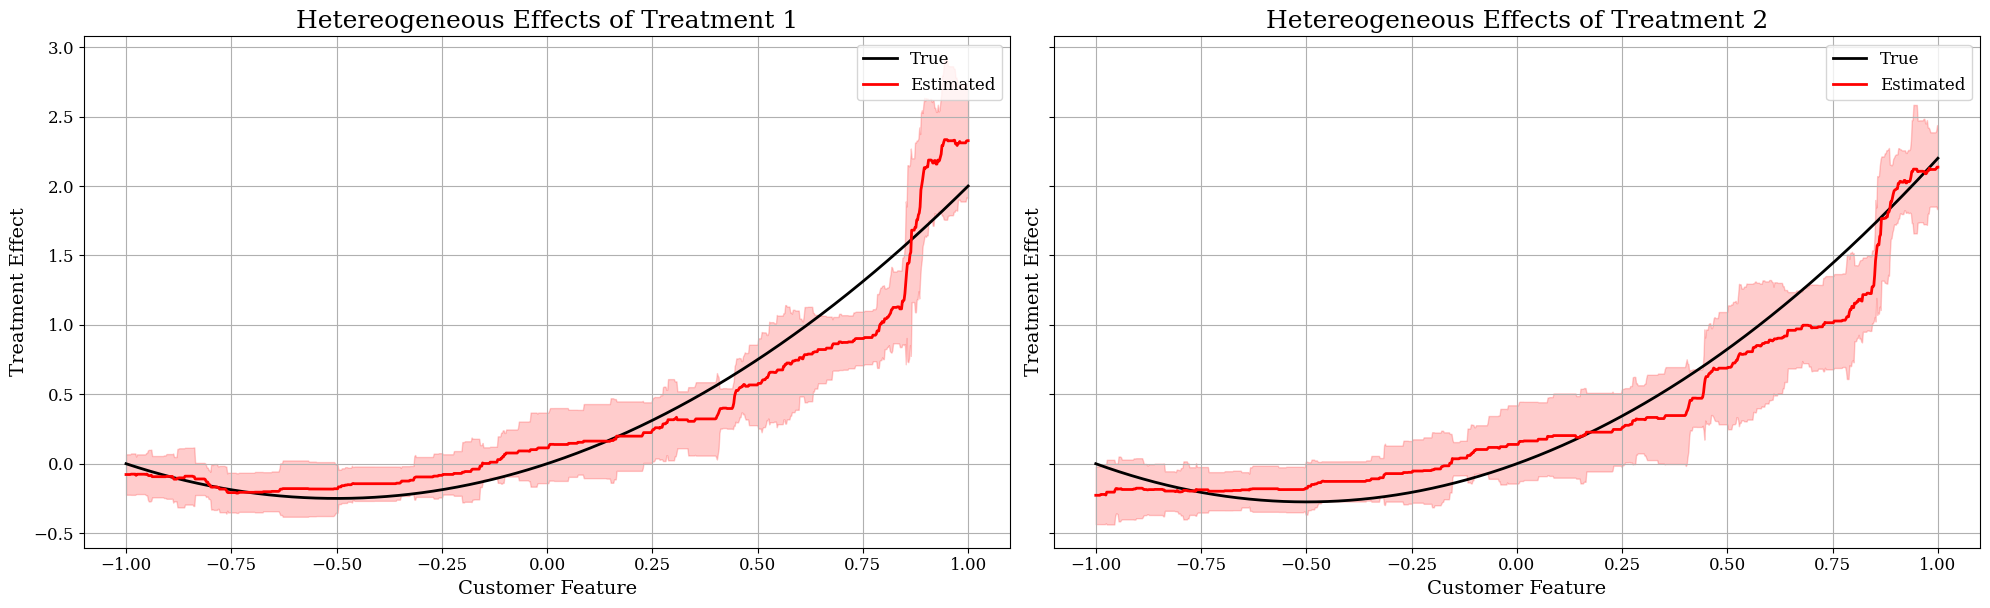

In [8]:
plot_hte(dgp, model=cfdml, ci=True)


Max_depth = 2
Average variance = 0.05446289857803355


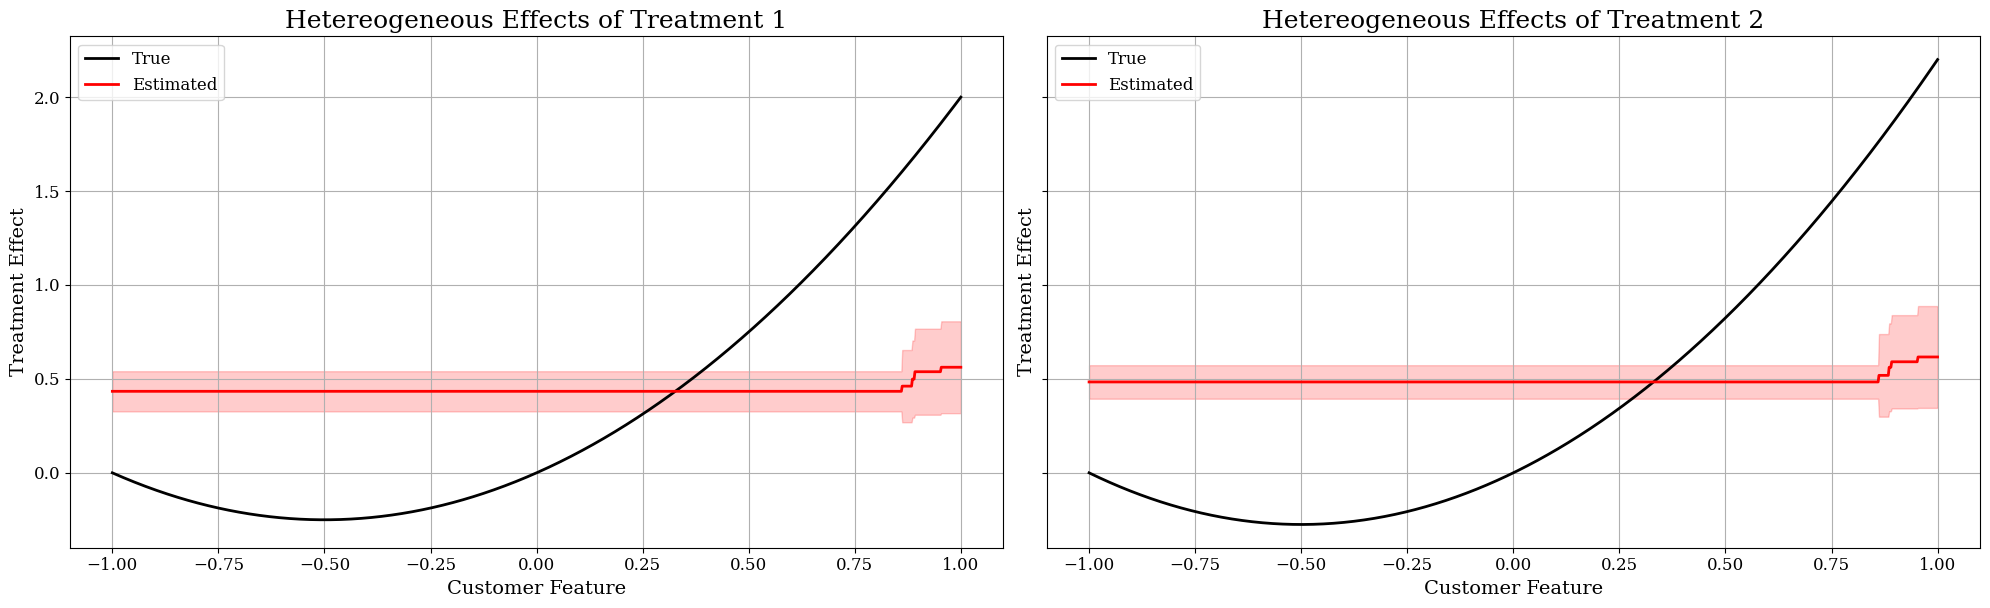


Max_depth = 3
Average variance = 0.04856137534609074


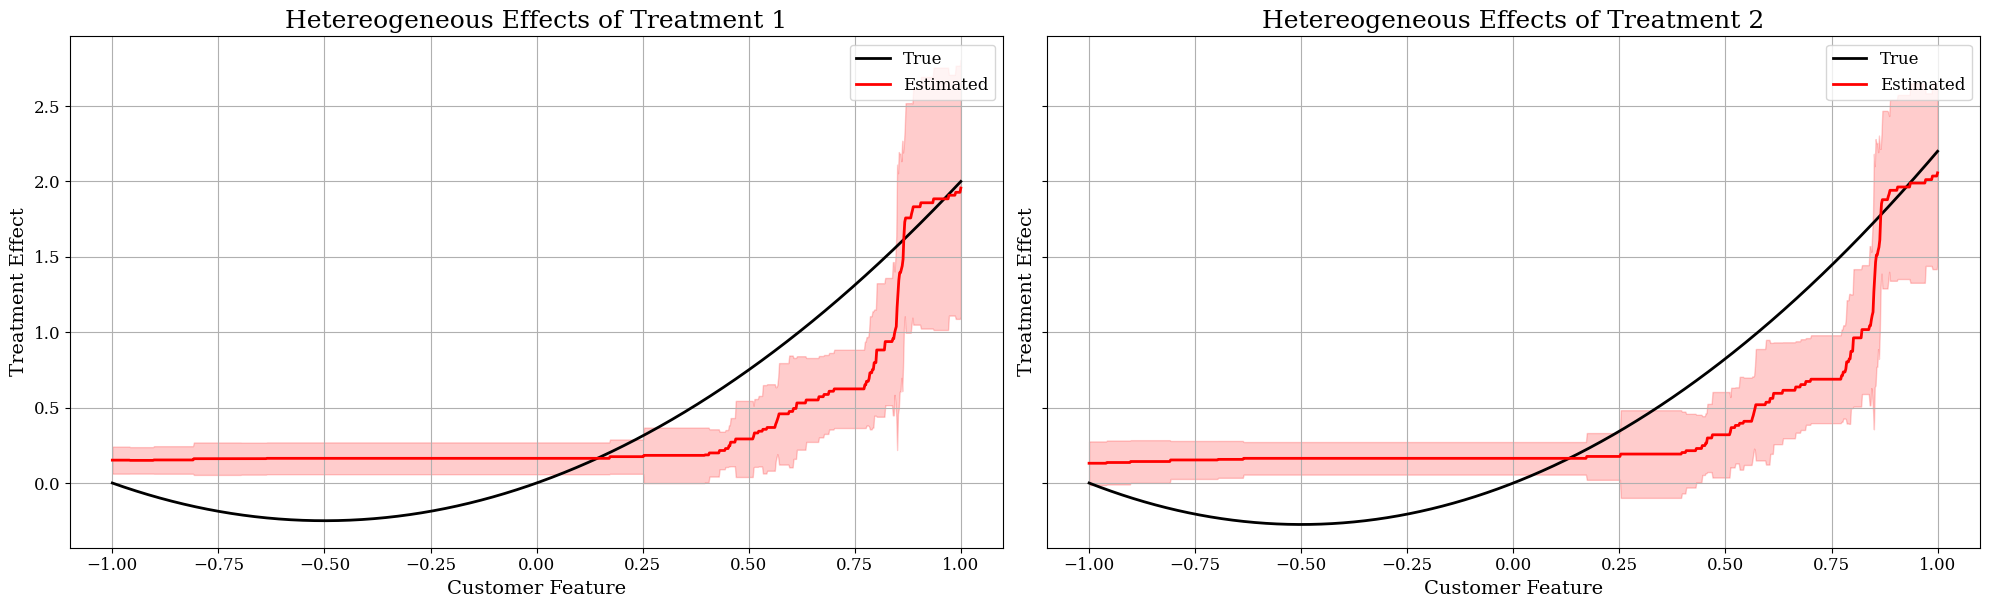


Max_depth = 4
Average variance = 0.03498752514784196


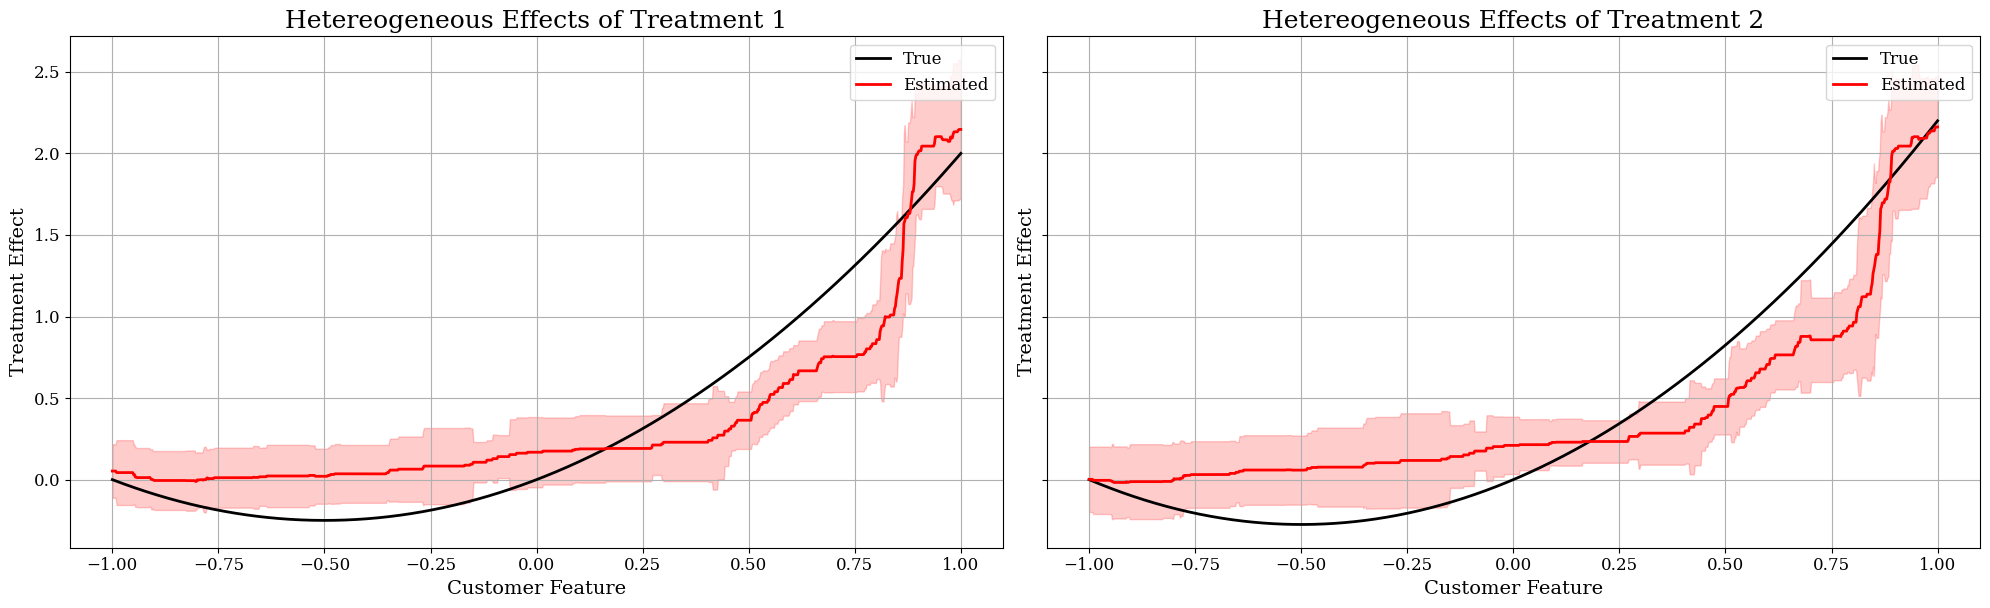


Max_depth = 5
Average variance = 0.03836469931669053


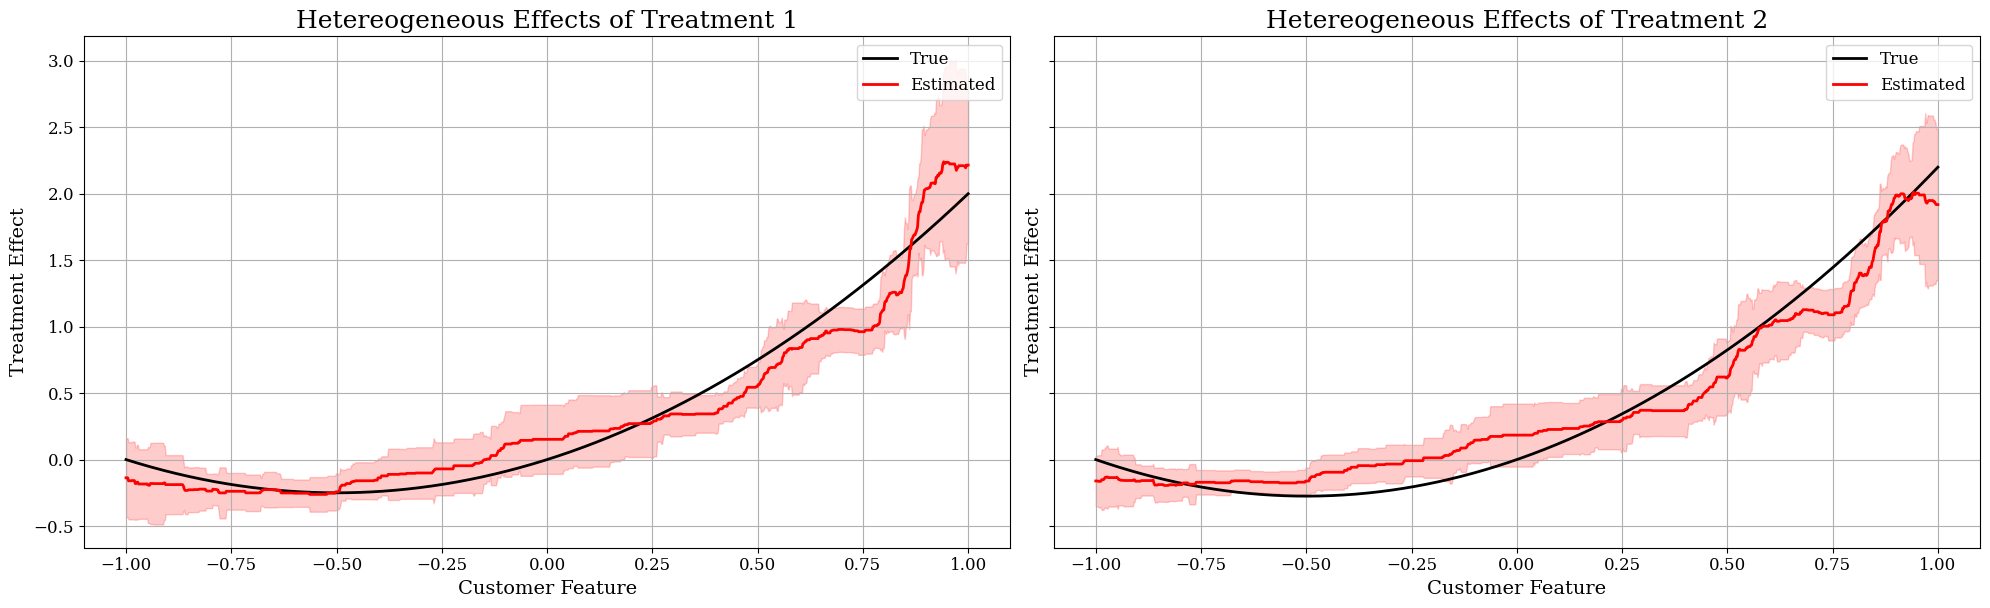


Max_depth = 6
Average variance = 0.051329149838438094


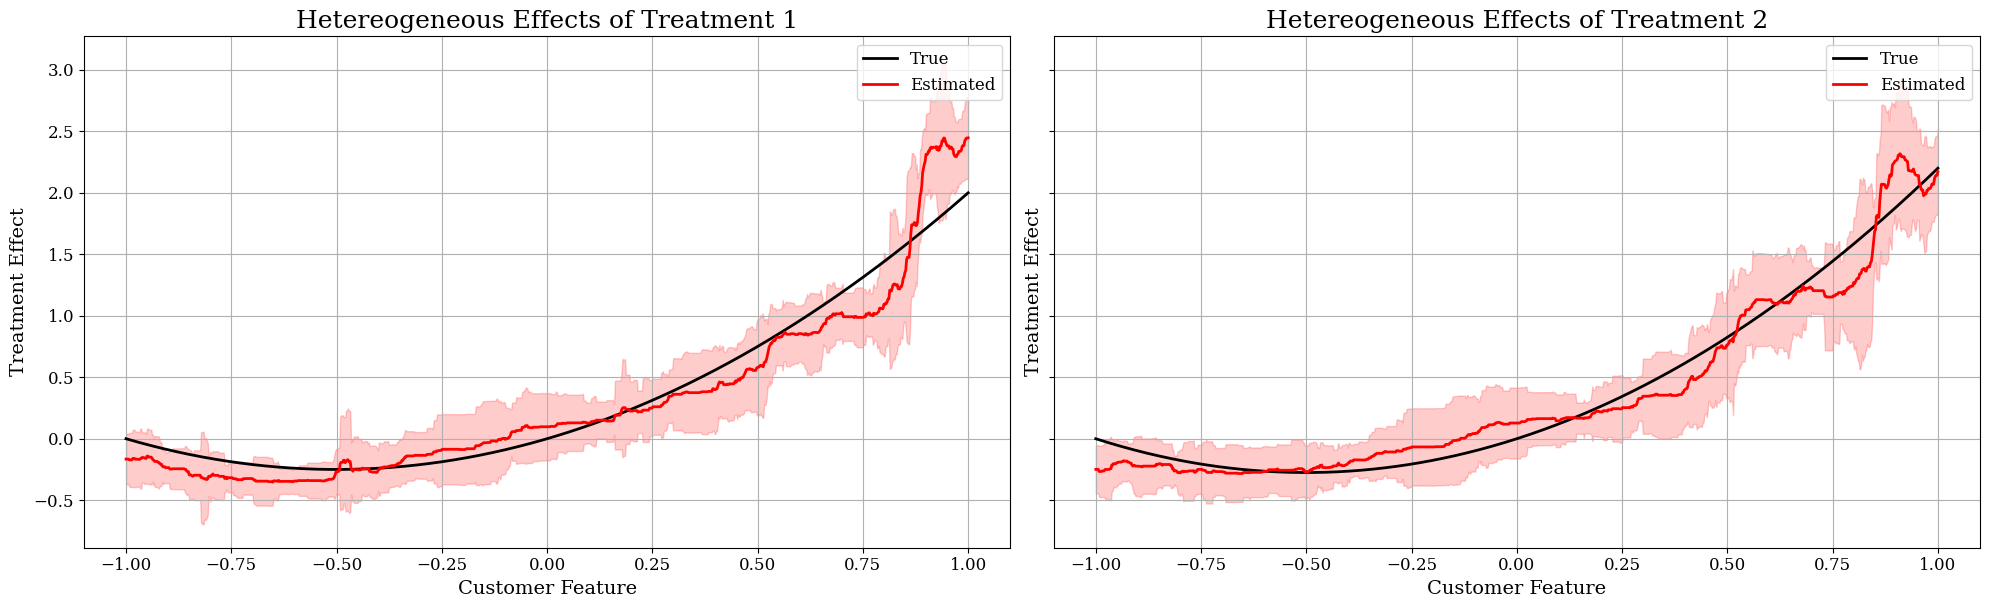


Max_depth = 7
Average variance = 0.054449377656358225


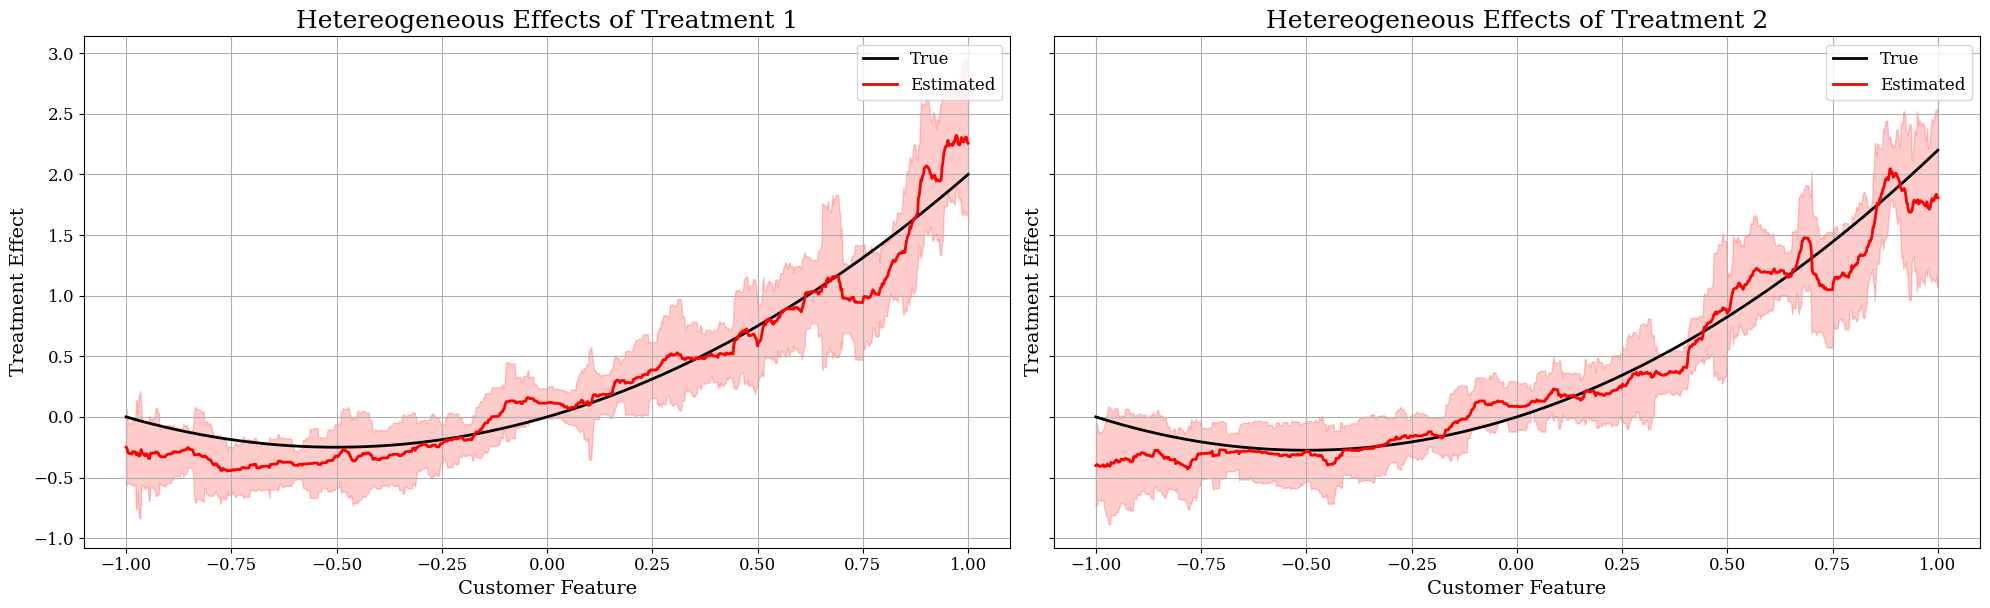


Max_depth = 8
Average variance = 0.06223960822047885


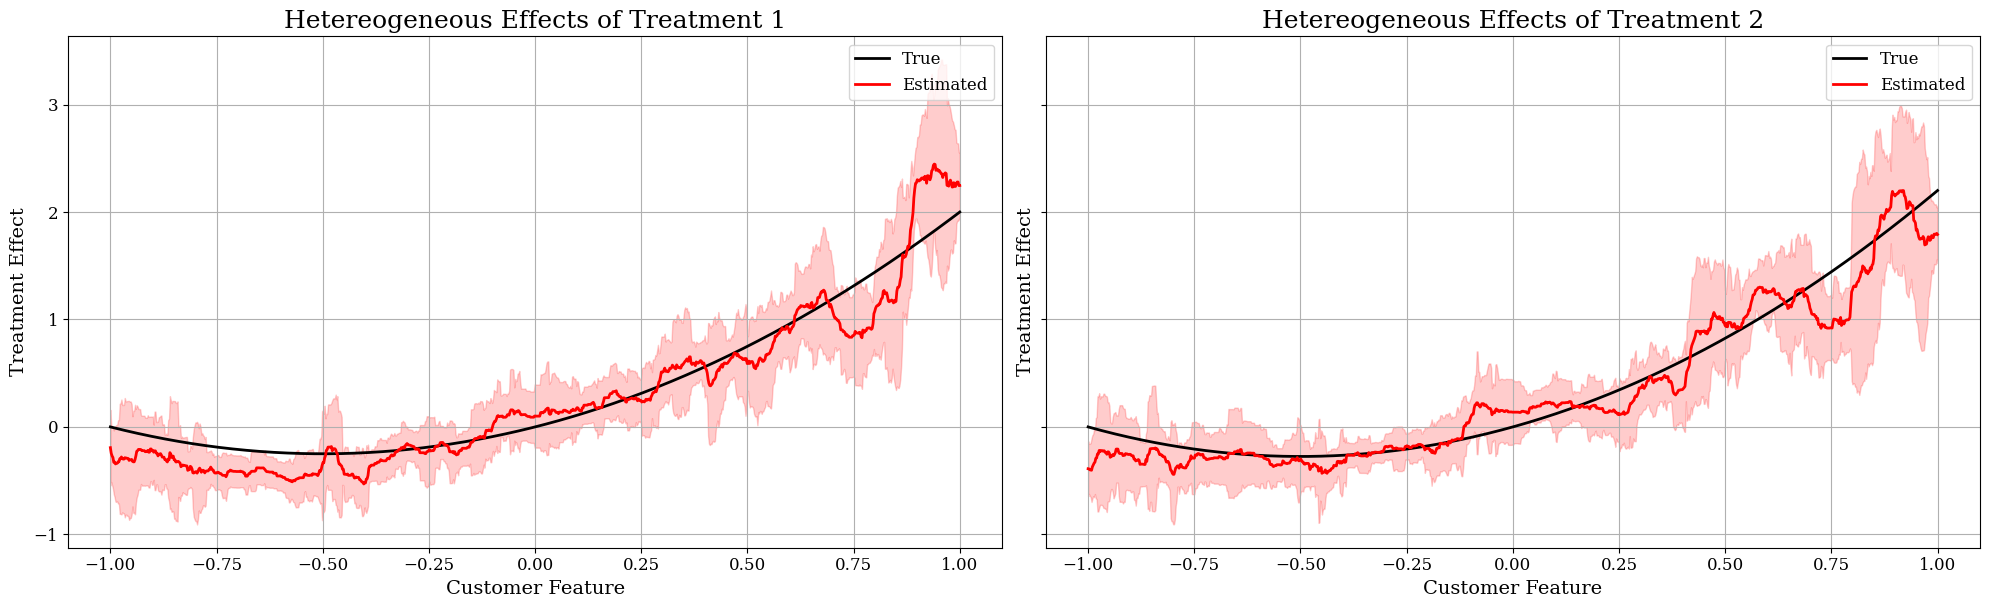


Max_depth = 9
Average variance = 0.07780533250303832


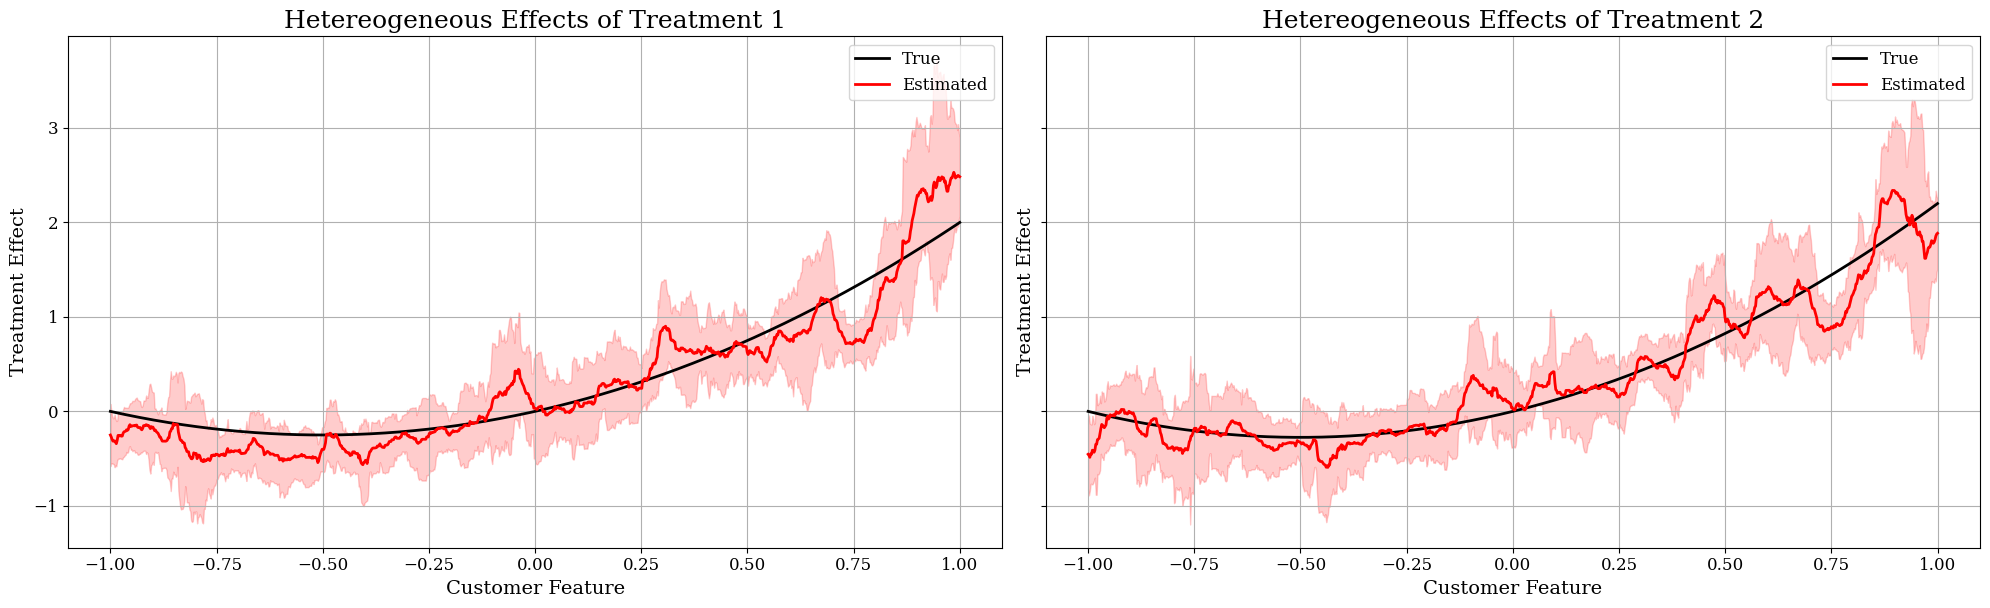


Max_depth = 10
Average variance = 0.09713303083549875


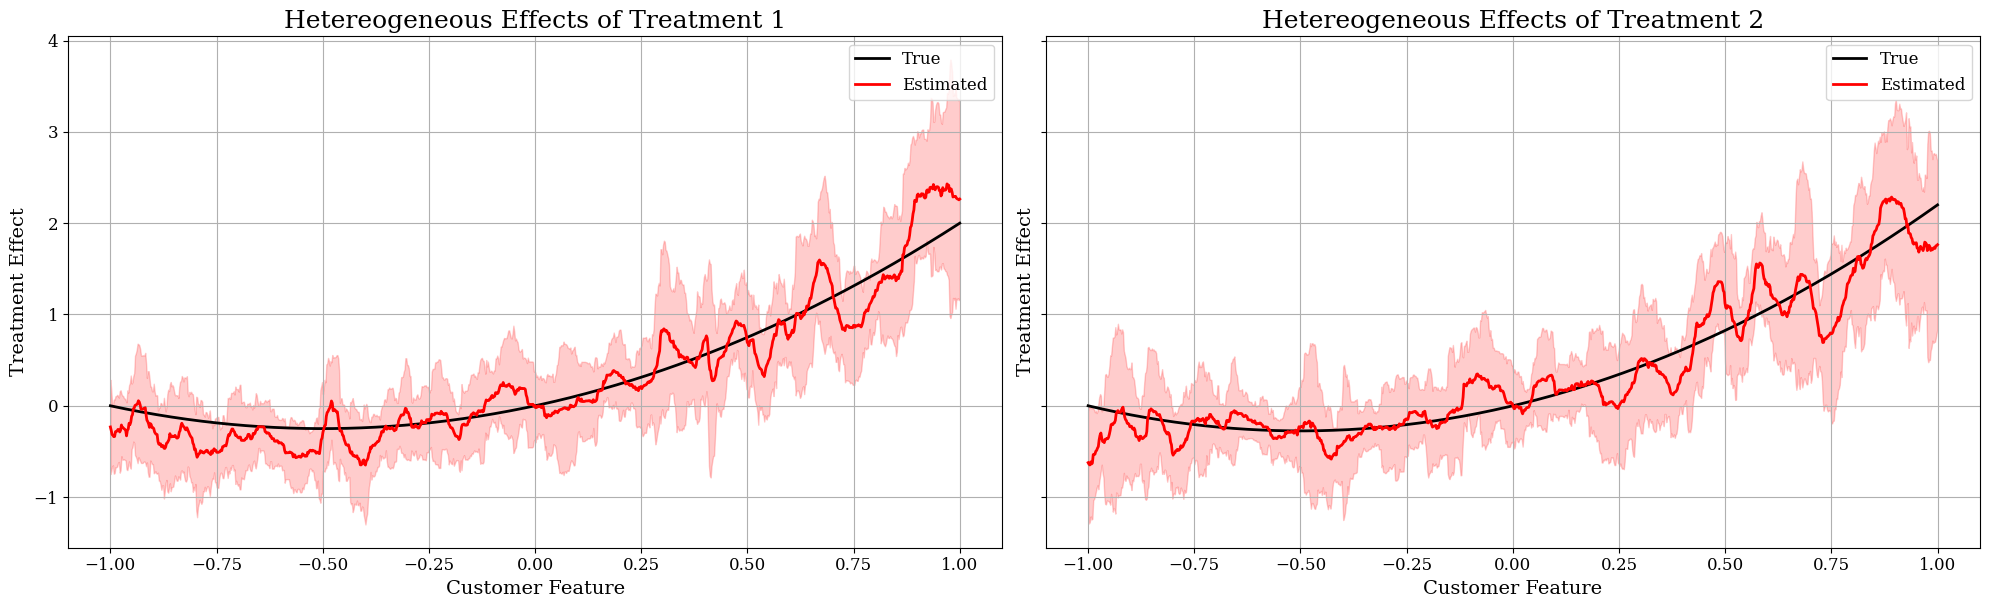

In [9]:
for max_depth in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
    print(f"\nMax_depth = {max_depth}")
    cfdml = CausalForestDML(
        n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
        n_estimators=100, max_depth=max_depth, n_jobs=-1, discrete_treatment=True
    ).fit(X=cust_features, Y=outcomes, T=treatments)

    avg_var = np.mean(cfdml.predict_incremental_effect(oos_cust_features)[1])
    print(f"Average variance = {avg_var}")

    plot_hte(dgp, model=cfdml, ci=True)

# Selection

In [10]:
selection, val_est = optimize(cfdml, oos_cust_features)

# Evaluation

In [11]:
val_true = obj_func(
    selection=selection, 
    cust_feautres=oos_cust_features, 
    demand_model=dgp,
)

result_df = pd.DataFrame({
    'Policy Value': [val_est, val_true, val_est - val_true]
}, index=['Estimated', 'True', "Winner's Curse"])
result_df

,Policy Value
Estimated,1.121112
True,1.019002
Winner's Curse,0.102109


In [12]:
del dgp, cfdml, selection, val_est, val_true, result_df 
del cust_features, treatments, outcomes, oos_cust_features

# Winner's Curse

In [13]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.1) for i in range(10)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

In [14]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   25.6s finished


In [15]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.7690 (0.0309)
  - Average Estimated Value: 2.1480 (0.0361)
  - Average Winner's Curse (%): 378.93% (21.10%)


# Estimating Winner's Curse

In [16]:
dgp = Targeting(**dgp_params)

cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'], seed=484)
oos_cust_features = dgp.sample_individuals(data_params['sample_size'])

## Standard Bootstrap

In [9]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


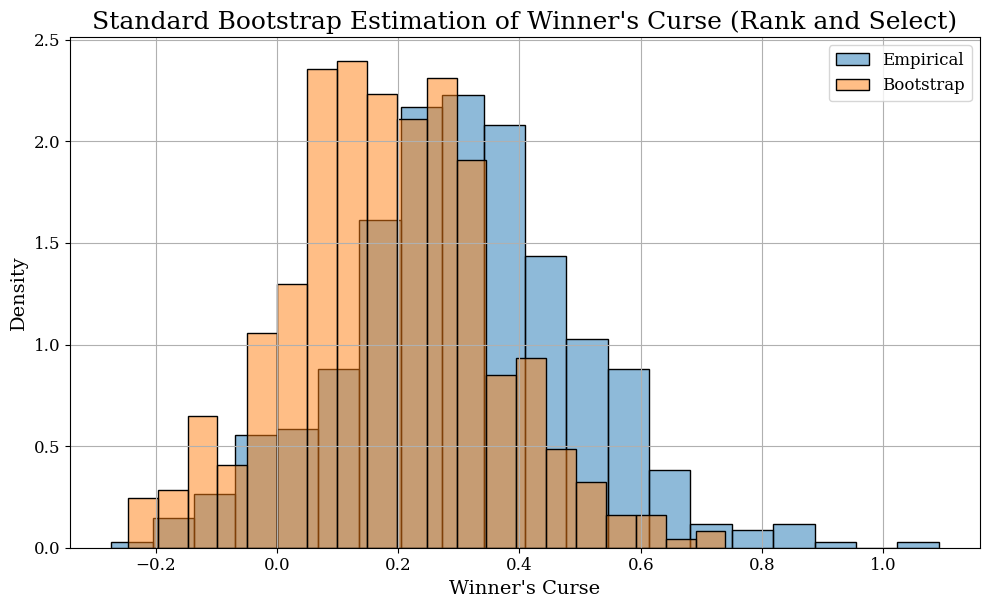

In [10]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_title(f'Standard Bootstrap Estimation of Winner\'s Curse ({display_name})', fontsize=title_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [11]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished


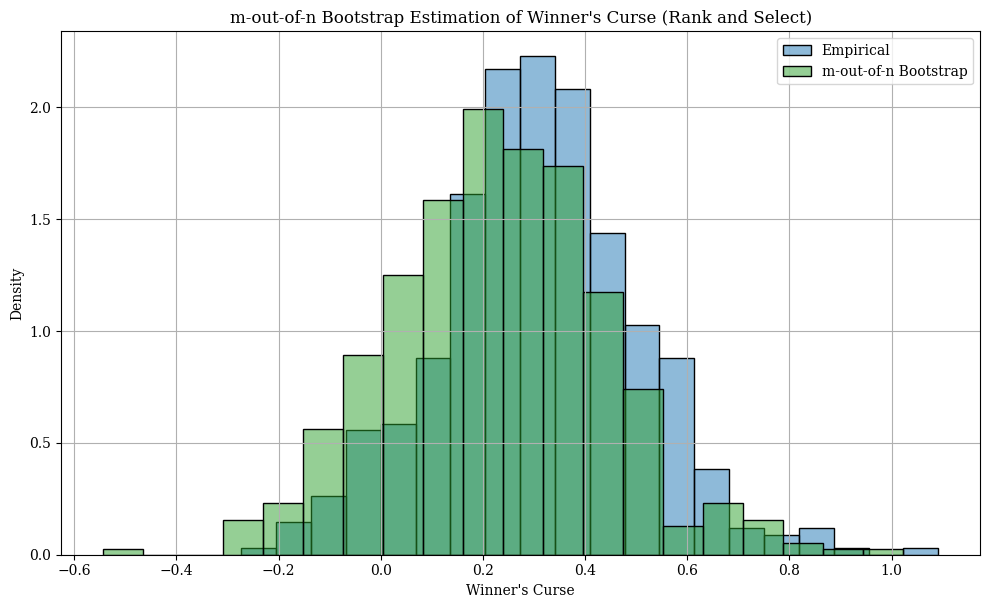

In [12]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'm-out-of-n Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [13]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=-0.45, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


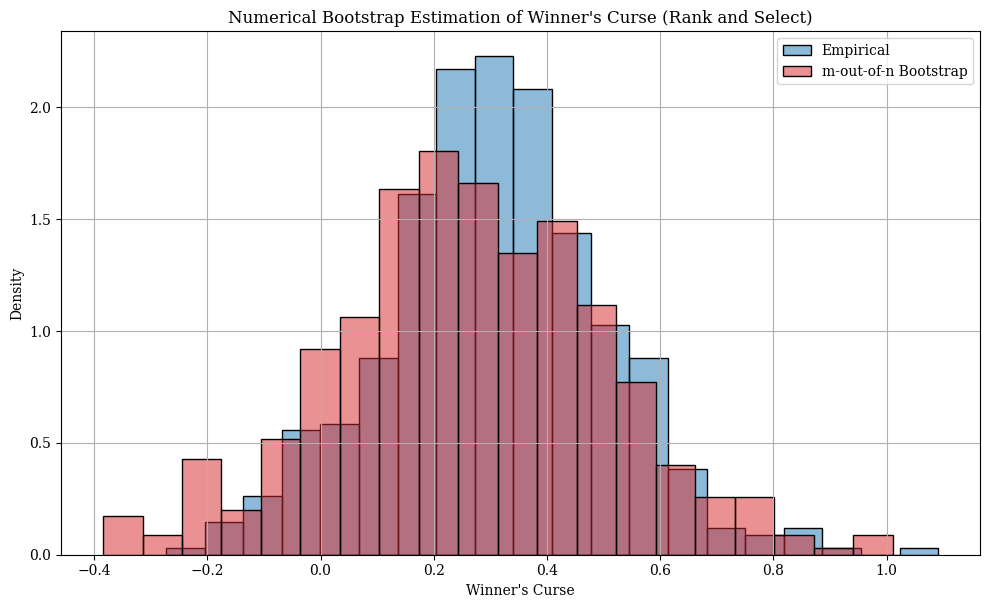

In [14]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'Numerical Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [5]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [ ]:
with open('results/targeting_bias_correction_large_sample.pkl', 'wb') as f:
    pickle.dump(wc_measures_dict, f)

with open('results/targeting_bias_correction_large_sample.pkl', 'rb') as f:
    wc_measures_dict = pickle.load(f)


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0627 (0.0187)
  - No Correction: 1.2408 (0.0256)
  - Standard Bootstrap: 1.1264 (0.0291)
  - m-out-of-n Bootstrap: 1.1119 (0.0295)
  - Numerical Bootstrap: 1.0917 (0.0306)
  - Bayes (Normal): 0.8626 (0.0200)
  - EB (Spike-and-Slab): 1.1053 (0.0254)
  - Conditional SI
(Andrews et al. 2024): 0.0780 (0.0974)
  - Hybrid SI
(Andrews et al. 2024): 0.7714 (0.0353)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 178.08% (22.69%)
  - Standard Bootstrap: 63.71% (26.59%)
  - m-out-of-n Bootstrap: 49.24% (26.14%)
  - Numerical Bootstrap: 28.98% (28.31%)
  - Bayes (Normal): -200.04% (21.76%)
  - EB (Spike-and-Slab): 42.62% (22.79%)
  - Conditional SI
(Andrews et al. 2024): -982.69% (95.26%)
  - Hybrid SI
(Andrews et al. 2024): -291.32% (33.21%)
Median Winner's Curse: 
  - No Correction: 182.98% (22.69%)
  - Standard Bootstrap: 67.91% (26.59%)
  - m-out-of-n Bootstrap: 43.39% (26.14%)
  - Numerical Bootstrap: 30.53% (28.

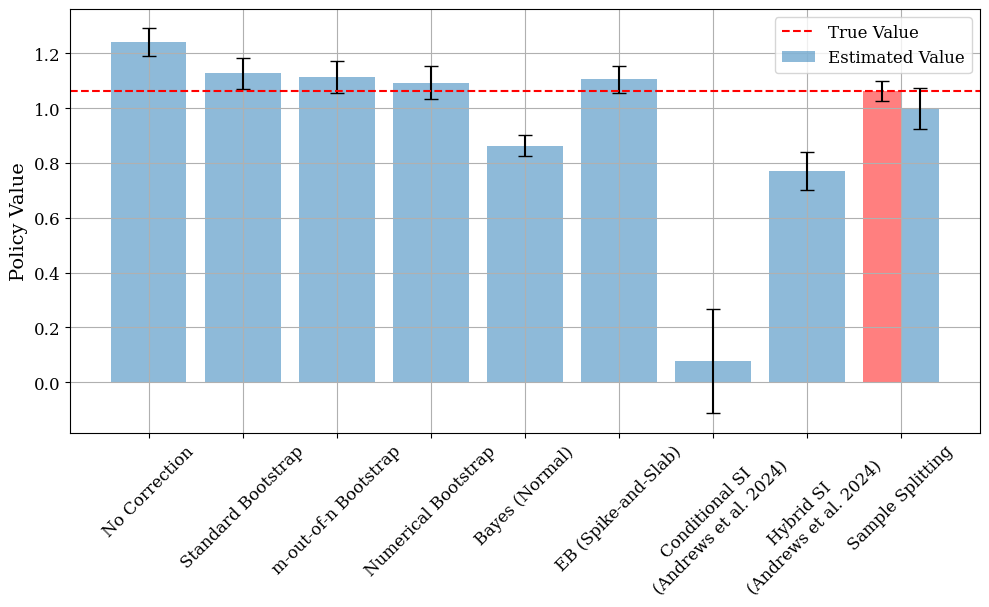

In [ ]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Comparative Statics

## Delta Tau

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [None, None], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

tau_list = [
    (1, 1.01),(1, 1.05), (1, 1.1), (2, 2.1), (3, 3.1), (1, 1.5)
]

In [ ]:
tau_result_dict = {tau: None for tau in tau_list}

for te_tuple in tau_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effect_vars'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    tau_result_dict[te_tuple] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.01)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 25.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.05)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (3, 3.1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.5)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.7min finished


In [ ]:
with open('results/targeting_delta_tau.pkl', 'wb') as f:
    pickle.dump(tau_result_dict, f)

with open('results/targeting_delta_tau.pkl', 'rb') as f:
    tau_result_dict = pickle.load(f)

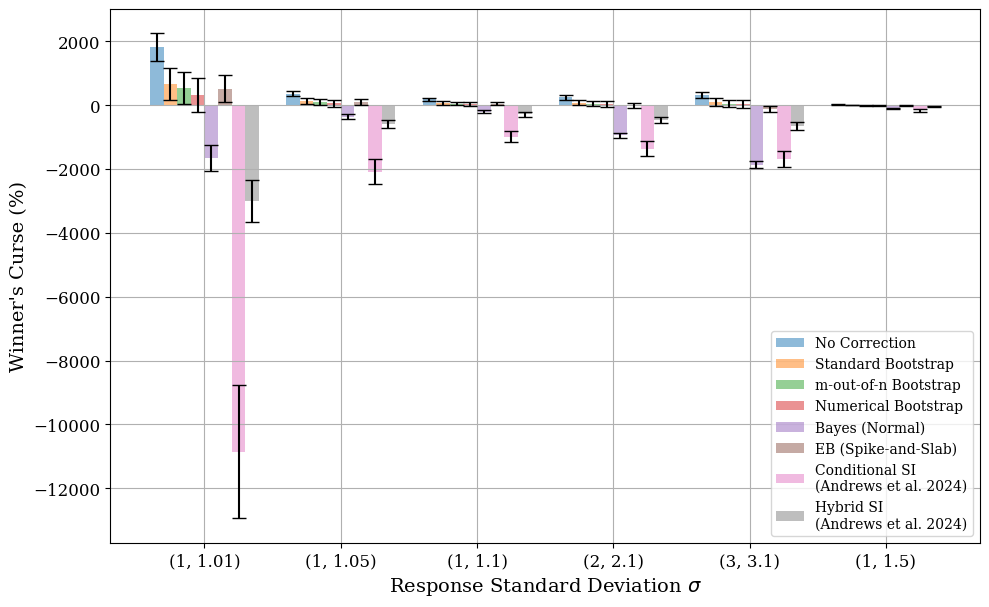

$\Delta\tau = 0.01$  \
                                             $(\tau_1, \tau_2)$ = (1, 1.01)   
No Correction                         Mean                          1819.48   
                                      Median                        1813.91   
                                      S.E.                           219.82   
Standard Bootstrap                    Mean                           669.08   
                                      Median                         655.86   
                                      S.E.                           258.47   
m-out-of-n Bootstrap                  Mean                           536.83   
                                      Median                         536.96   
                                      S.E.                           255.13   
Numerical Bootstrap                   Mean                           309.48   
                                      Median                         317.87   
                                      S.E.                           274.40   
Bayes (Normal)                        Mean                         -1650.49   
                                      Median                       -1463.72   
                                      S.E.                           207.98   
EB (Spike-and-Slab)                   Mean                           517.39   
                                      Median                         593.88   
                                      S.E.                           221.31   
Conditional SI\n(Andrews et al. 2024) Mean                        -10853.29   
                                      Median                       -8056.38   
                                      S.E.                          1066.24   
Hybrid SI\n(Andrews et al. 2024)      Mean                         -3001.99   
                                      Median                       -2632.37   
                                      S.E.                           338.15   

                                                        $\Delta\tau = 0.05$  \
                                             $(\tau_1, \tau_2)$ = (1, 1.05)   
No Correction                         Mean                           362.37   
                                      Median                         363.77   
                                      S.E.                            44.46   
Standard Bootstrap                    Mean                           133.21   
                                      Median                         135.62   
                                      S.E.                            52.43   
m-out-of-n Bootstrap                  Mean                           101.70   
                                      Median                          94.61   
                                      S.E.                            51.57   
Numerical Bootstrap                   Mean                            61.40   
                                      Median                          54.51   
                                      S.E.                            55.20   
Bayes (Normal)                        Mean                          -359.44   
                                      Median                        -313.79   
                                      S.E.                            42.31   
EB (Spike-and-Slab)                   Mean                            96.25   
                                      Median                         110.24   
                                      S.E.                            44.79   
Conditional SI\n(Andrews et al. 2024) Mean                         -2081.22   
                                      Median                       -1563.47   
                                      S.E.                           200.10   
Hybrid SI\n(Andrews et al. 2024)      Mean                          -596.74   
                                      Median                        -526.75   
                          

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(tau_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in tau_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(tau_list)), labels=tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

sample_size_list = [100, 500, 1000, 2500, 5000]

In [ ]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size= {sample_size}')

    data_params['sample_size'] = sample_size    

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size= 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 26.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 31.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 39.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 1000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 41.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 52.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 24.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 68.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 86.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 44.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 116.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 149.4min finished


In [ ]:
with open('results/targeting_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

with open('results/targeting_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

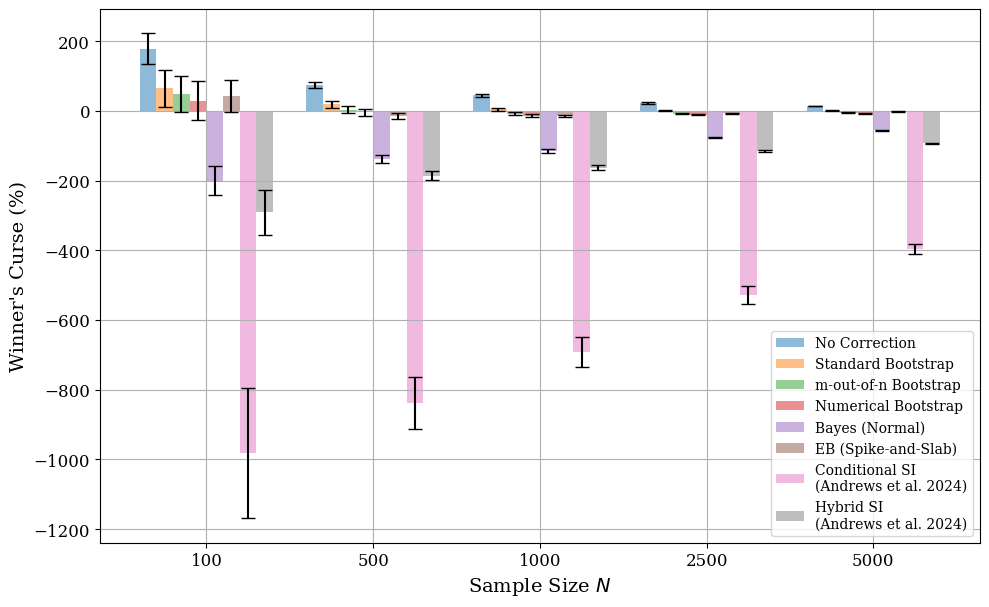

$N=100$  $N=500$  $N=1000$  \
No Correction                         Mean     178.08    73.31     44.86   
                                      Median   182.98    73.44     47.26   
                                      S.E.      22.69     4.38      2.03   
Standard Bootstrap                    Mean      64.48    18.31      4.35   
                                      Median    64.19    16.71      3.80   
                                      S.E.      26.69     4.94      2.27   
m-out-of-n Bootstrap                  Mean      49.17     2.89     -8.18   
                                      Median    50.06     0.14     -8.53   
                                      S.E.      26.12     4.92      2.27   
Numerical Bootstrap                   Mean      29.20    -4.32    -14.39   
                                      Median    26.61   -13.68    -15.97   
                                      S.E.      28.06     5.22      2.39   
Bayes (Normal)                        Mean    -200.04  -137.88   -114.63   
                                      Median  -176.27  -131.76   -113.14   
                                      S.E.      21.76     5.50      2.68   
EB (Spike-and-Slab)                   Mean      42.62   -15.47    -14.74   
                                      Median    47.42   -18.80    -11.90   
                                      S.E.      22.79     4.27      1.96   
Conditional SI\n(Andrews et al. 2024) Mean    -982.69  -838.16   -692.54   
                                      Median  -702.97  -587.86   -481.76   
                                      S.E.      95.26    37.90     21.72   
Hybrid SI\n(Andrews et al. 2024)      Mean    -291.40  -185.84   -162.98   
                                      Median  -253.12  -185.45   -161.70   
                                      S.E.      33.22     6.28      3.15   

                                              $N=2500$  $N=5000$  
No Correction                         Mean       22.56     13.65  
                                      Median     24.35     14.75  
                                      S.E.        0.87      0.47  
Standard Bootstrap                    Mean        0.30      0.53  
                                      Median      2.25     -0.88  
                                      S.E.        0.97      0.53  
m-out-of-n Bootstrap                  Mean       -8.50     -5.38  
                                      Median     -8.42     -6.47  
                                      S.E.        0.96      0.53  
Numerical Bootstrap                   Mean      -11.12     -7.04  
                                      Median    -10.62     -8.31  
                                      S.E.        1.04      0.57  
Bayes (Normal)                        Mean      -76.64    -55.34  
                                      Median    -68.24    -50.06  
                                      S.E.        1.27      0.69  
EB (Spike-and-Slab)                   Mean       -7.04     -2.36  
                                      Median     -6.61     -0.92  
                                      S.E.        0.84      0.48  
Conditional SI\n(Andrews et al. 2024) Mean     -528.00   -395.49  
                                      Median   -308.60   -227.13  
                                      S.E.       13.17      7.14  
Hybrid SI\n(Andrews et al. 2024)      Mean     -115.87    -92.43  
                                      Median   -113.60    -94.31  
                                      S.E.        1.36      0.75

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Response STD

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [ ]:
response_std_list = [0.5, 1, 2, 3, 4, 5]

response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nNoise Standard Deviation= {response_std}')

    dgp_params['noise_var'] = UnivariateGaussian(0, response_std)  

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Standard Deviation= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 2
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Standard Deviation= 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.8min finished


In [ ]:
with open('results/targeting_response_std.pkl', 'wb') as f:
    pickle.dump(response_std_result_dict, f)

with open('results/targeting_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

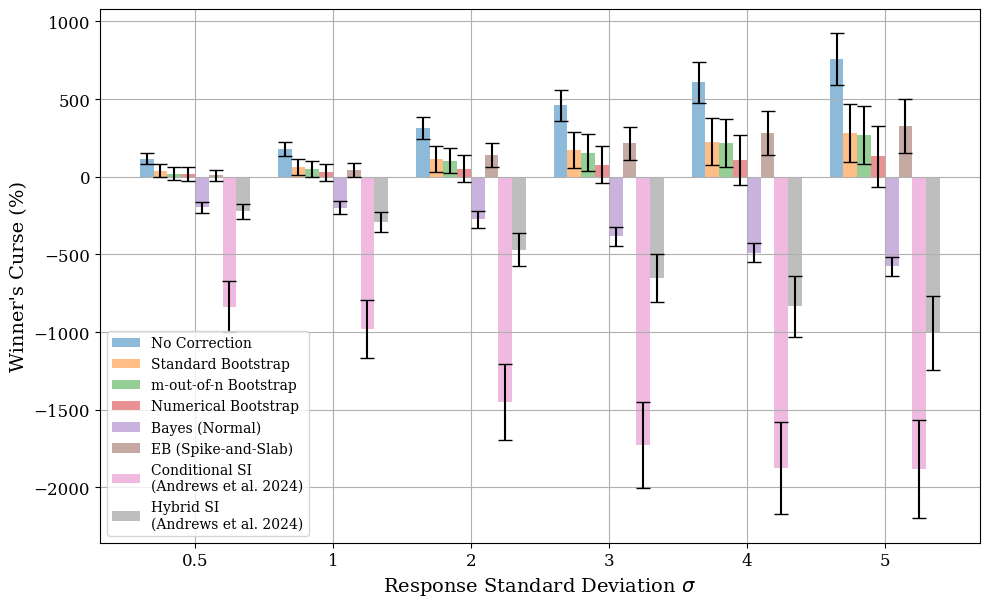

$\sigma=0.5$  $\sigma=1$  \
No Correction                         Mean          116.87      178.08   
                                      Median        106.97      182.98   
                                      S.E.           17.83       22.69   
Standard Bootstrap                    Mean           37.09       64.77   
                                      Median         22.04       67.31   
                                      S.E.           21.40       26.64   
m-out-of-n Bootstrap                  Mean           19.82       49.46   
                                      Median          2.21       46.15   
                                      S.E.           20.93       26.18   
Numerical Bootstrap                   Mean           15.24       29.49   
                                      Median         -7.81       20.97   
                                      S.E.           22.78       28.09   
Bayes (Normal)                        Mean         -197.89     -200.04   
                                      Median       -186.96     -176.27   
                                      S.E.           17.76       21.76   
EB (Spike-and-Slab)                   Mean            7.98       42.62   
                                      Median         -0.58       47.42   
                                      S.E.           17.02       22.79   
Conditional SI\n(Andrews et al. 2024) Mean         -835.74     -982.69   
                                      Median       -600.63     -702.97   
                                      S.E.           82.33       95.26   
Hybrid SI\n(Andrews et al. 2024)      Mean         -222.96     -291.34   
                                      Median       -207.24     -252.56   
                                      S.E.           24.42       33.21   

                                              $\sigma=2$  $\sigma=3$  \
No Correction                         Mean        314.79      459.17   
                                      Median      310.53      442.70   
                                      S.E.         36.36       51.99   
Standard Bootstrap                    Mean        114.98      169.25   
                                      Median      114.48      187.61   
                                      S.E.         41.59       59.13   
m-out-of-n Bootstrap                  Mean        103.65      155.79   
                                      Median       93.86      149.17   
                                      S.E.         41.51       59.49   
Numerical Bootstrap                   Mean         50.74       77.41   
                                      Median       47.82       74.34   
                                      S.E.         43.93       61.70   
Bayes (Normal)                        Mean       -275.38     -384.27   
                                      Median     -261.49     -385.35   
                                      S.E.         28.22       31.01   
EB (Spike-and-Slab)                   Mean        137.52      214.42   
                                      Median      139.45      190.49   
                                      S.E.         39.64       55.58   
Conditional SI\n(Andrews et al. 2024) Mean      -1449.77    -1729.08   
                                      Median    -1184.26    -1448.11   
                                      S.E.        125.83      141.05   
Hybrid SI\n(Andrews et al. 2024)      Mean       -469.77     -653.95   
                                      Median     -447.05     -562.88   
                                      S.E.         54.37       78.64   

                                              $\sigma=4$  $\sigma=5$  
No Correction                         Mean        607.76      758.62  
                                      Median      582.74      736.79  
                                      S.E.         68.18       84.41  
Standard Bootstrap                    Mean        224.60      282.99  
                                      M

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Functional Form

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': None, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [ ]:
char_func_dict = {
    r'$x$': lambda x: x,
    r'$x^2 + x$': lambda x: x**2 + x,
    r'$x^3$': lambda x: x**3,
    r'$|x|$': lambda x: np.abs(x),
}

char_func_result_dict = {k: None for k in char_func_dict.keys()}
for char_func in char_func_dict.keys():
    print(f'\nCharacterizing Function= {char_func}')

    dgp_params['char_func'] = char_func_dict[char_func]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    char_func_result_dict[char_func] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )



Characterizing Function= $x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^2 + x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^3$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $|x|$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.3min
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.4min finished


In [ ]:
with open('results/targeting_char_func.pkl', 'wb') as f:
    pickle.dump(char_func_result_dict, f)

with open('results/targeting_char_func.pkl', 'rb') as f:
    char_func_result_dict = pickle.load(f)

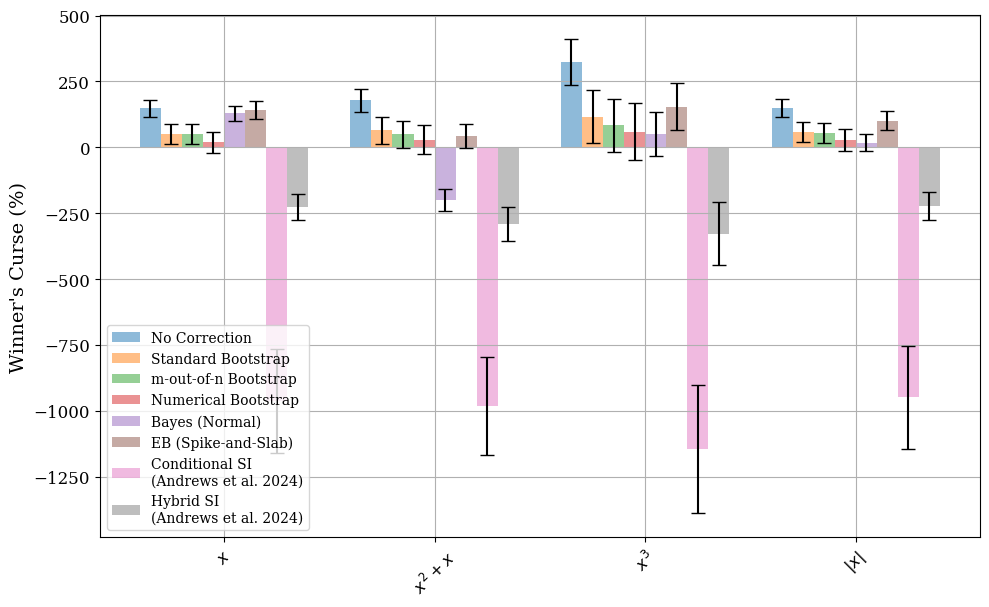

$x$  $x^2 + x$    $x^3$  \
No Correction                         Mean    147.89     178.08   322.90   
                                      Median  147.86     182.98   301.62   
                                      S.E.     16.94      22.69    44.57   
Standard Bootstrap                    Mean     50.49      63.73   116.32   
                                      Median   49.96      64.26    86.28   
                                      S.E.     19.36      26.66    51.56   
m-out-of-n Bootstrap                  Mean     49.00      49.59    83.20   
                                      Median   47.74      51.27    75.70   
                                      S.E.     19.61      26.18    51.12   
Numerical Bootstrap                   Mean     19.56      29.11    59.79   
                                      Median   13.28      28.43    59.72   
                                      S.E.     20.27      28.22    54.79   
Bayes (Normal)                        Mean    128.47    -200.04    50.55   
                                      Median  131.54    -176.27    68.67   
                                      S.E.     15.31      21.76    42.33   
EB (Spike-and-Slab)                   Mean    142.97      42.62   153.51   
                                      Median  143.39      47.42   169.59   
                                      S.E.     17.54      22.79    45.68   
Conditional SI\n(Andrews et al. 2024) Mean   -963.08    -982.69 -1144.84   
                                      Median -643.64    -702.97  -849.86   
                                      S.E.     99.80      95.26   124.40   
Hybrid SI\n(Andrews et al. 2024)      Mean   -226.00    -291.31  -327.41   
                                      Median -216.23    -251.60  -300.49   
                                      S.E.     25.15      33.21    61.18   

                                               $|x|$  
No Correction                         Mean    150.36  
                                      Median  142.04  
                                      S.E.     17.28  
Standard Bootstrap                    Mean     57.63  
                                      Median   55.08  
                                      S.E.     19.79  
m-out-of-n Bootstrap                  Mean     53.86  
                                      Median   52.04  
                                      S.E.     19.78  
Numerical Bootstrap                   Mean     27.70  
                                      Median   23.53  
                                      S.E.     20.66  
Bayes (Normal)                        Mean     17.59  
                                      Median   21.30  
                                      S.E.     15.77  
EB (Spike-and-Slab)                   Mean    100.75  
                                      Median  107.03  
                                      S.E.     18.04  
Conditional SI\n(Andrews et al. 2024) Mean   -948.41  
                                      Median -632.46  
                                      S.E.     99.53  
Hybrid SI\n(Andrews et al. 2024)      Mean   -223.25  
                                      Median -205.59  
                                      S.E.     26.52

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = char_func_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for char_func in char_func_dict.keys():
    data[char_func] = {}

    data[char_func]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[char_func][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in char_func_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(char_func_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(char_func_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in char_func_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in char_func_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(char_func_dict.keys())), 
    labels=char_func_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Noise Distribution

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [ ]:
noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    'Student T (Dof = 100)': StudentT(100), 
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

noise_dstn_result_dict = {k: None for k in noise_dstn_dict.keys()}

for noise_dstn in noise_dstn_dict.keys():
    print(f'\nNoise Distribution= {noise_dstn}')

    dgp_params['noise_var'] = noise_dstn_dict[noise_dstn]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_dstn] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution= Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution= Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.3min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution= Student T (Dof = 100)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution= Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution= Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.8min finished


In [ ]:
with open('results/targeting_noise_dstn.pkl', 'wb') as f:
    pickle.dump(noise_dstn_result_dict, f)

with open('results/targeting_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

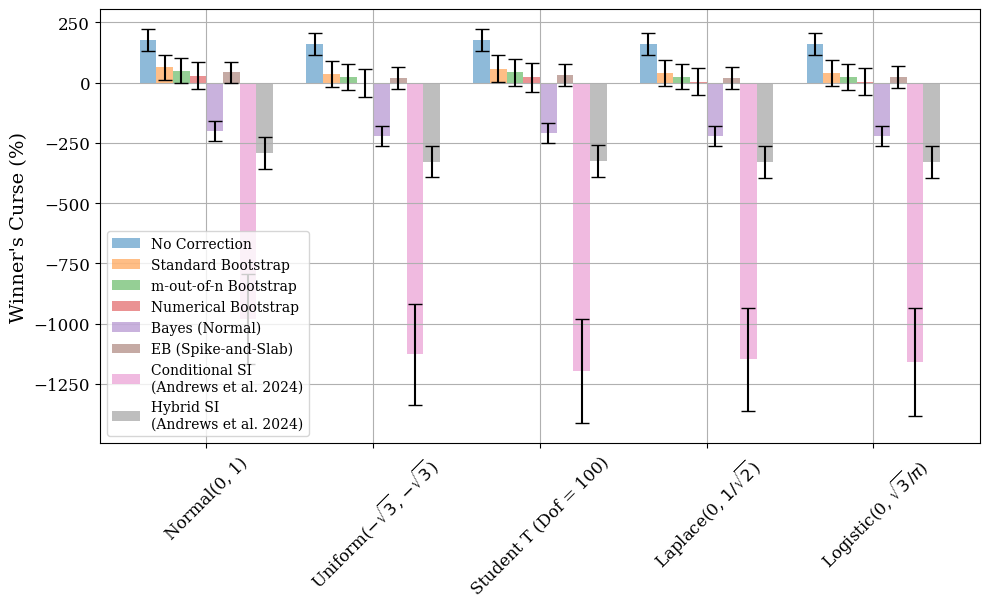

Normal(0, 1)  \
No Correction                         Mean          178.08   
                                      Median        182.98   
                                      S.E.           22.69   
Standard Bootstrap                    Mean           63.82   
                                      Median         67.21   
                                      S.E.           26.60   
m-out-of-n Bootstrap                  Mean           50.45   
                                      Median         46.84   
                                      S.E.           26.42   
Numerical Bootstrap                   Mean           28.90   
                                      Median         23.73   
                                      S.E.           28.37   
Bayes (Normal)                        Mean         -200.04   
                                      Median       -176.27   
                                      S.E.           21.76   
EB (Spike-and-Slab)                   Mean           42.62   
                                      Median         47.42   
                                      S.E.           22.79   
Conditional SI\n(Andrews et al. 2024) Mean         -982.69   
                                      Median       -702.97   
                                      S.E.           95.26   
Hybrid SI\n(Andrews et al. 2024)      Mean         -291.37   
                                      Median       -252.11   
                                      S.E.           33.22   

                                              Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction                         Mean                               161.02   
                                      Median                             156.52   
                                      S.E.                                23.44   
Standard Bootstrap                    Mean                                36.11   
                                      Median                              16.80   
                                      S.E.                                27.61   
m-out-of-n Bootstrap                  Mean                                22.61   
                                      Median                               5.69   
                                      S.E.                                27.38   
Numerical Bootstrap                   Mean                                -0.64   
                                      Median                             -16.75   
                                      S.E.                                29.16   
Bayes (Normal)                        Mean                              -222.29   
                                      Median                            -220.93   
                                      S.E.                                20.74   
EB (Spike-and-Slab)                   Mean                                18.64   
                                      Median                              19.87   
                                      S.E.                                23.41   
Conditional SI\n(Andrews et al. 2024) Mean                             -1128.12   
                                      Median                            -827.96   
                                      S.E.                               106.41   
Hybrid SI\n(Andrews et al. 2024)      Mean                              -327.74   
                                      Median                            -326.40   
                                      S.E.                                33.44   

                                              Student T (Dof = 100)  \
No Correction                         Mean                   177.13   
                                      Median                 167.78   
                                      S.E.                    23.93   
Standard Bootstrap                    Mean                    58.36   
                                      Median                  38

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Multiple Treatments

In [16]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': None, 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': None, 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [17]:
n_treatments_list = [2, 4, 6, 8, 10]
delta_tau = 0.1
n_treatments_result_dict = {n_treatments: None for n_treatments in n_treatments_list}

for n_treatments in n_treatments_list:
    print(f'\nNumber of Treatments= {n_treatments}')

    dgp_params['base_effect_vars'] = [PointMass(1 + i * delta_tau) for i in range(n_treatments)]
    experiment_params['estimator']['params']['n_treatments'] = n_treatments

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    n_treatments_result_dict[n_treatments] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Treatments= 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 10.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 29.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 37.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 15.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 41.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 53.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 21.2min
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 62.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 77.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 35.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 99.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 126.8min finished


In [18]:
with open('results/targeting_n_treatments.pkl', 'wb') as f:
    pickle.dump(n_treatments_result_dict, f)

with open('results/targeting_n_treatments.pkl', 'rb') as f:
    n_treatments_result_dict = pickle.load(f)

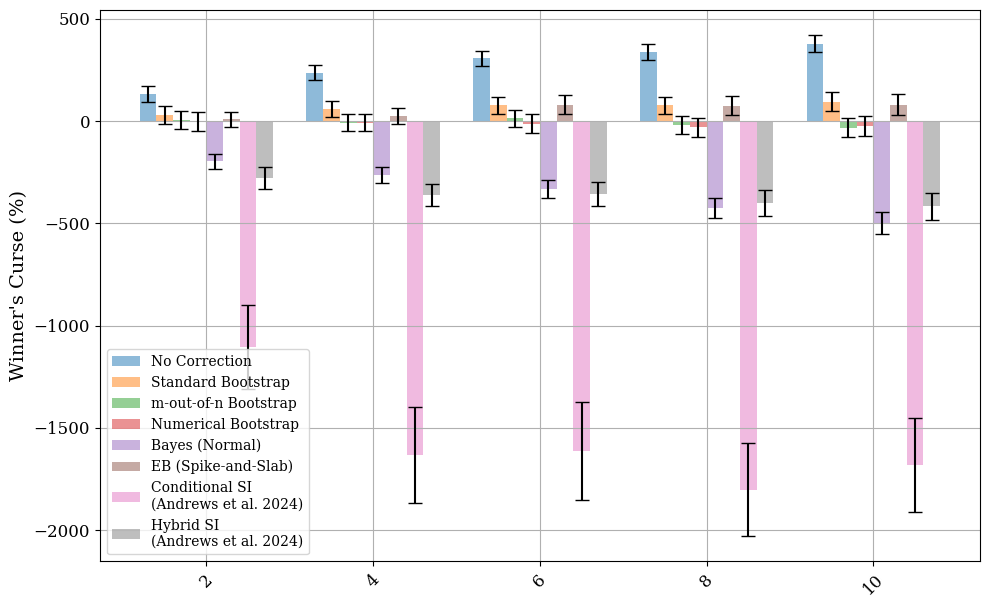

2        4        6   \
No Correction                         Mean     130.72   237.25   306.94   
                                      Median   124.98   232.79   302.70   
                                      S.E.      19.89    17.55    19.22   
Standard Bootstrap                    Mean      30.91    57.44    76.25   
                                      Median    25.84    61.61    81.33   
                                      S.E.      22.65    20.03    21.78   
m-out-of-n Bootstrap                  Mean       3.10    -7.29    13.39   
                                      Median     1.07   -12.31    15.10   
                                      S.E.      22.41    20.18    21.74   
Numerical Bootstrap                   Mean      -0.86    -8.21   -13.14   
                                      Median   -13.06    -5.30   -17.61   
                                      S.E.      24.03    21.34    23.35   
Bayes (Normal)                        Mean    -196.94  -262.65  -333.77   
                                      Median  -183.26  -245.19  -325.31   
                                      S.E.      19.53    20.58    22.62   
EB (Spike-and-Slab)                   Mean       9.13    26.39    80.82   
                                      Median     6.60    18.71    89.75   
                                      S.E.      18.83    19.65    22.48   
Conditional SI\n(Andrews et al. 2024) Mean   -1106.05 -1630.71 -1613.49   
                                      Median  -805.94 -1388.19 -1343.46   
                                      S.E.     104.41   120.09   121.51   
Hybrid SI\n(Andrews et al. 2024)      Mean    -279.10  -361.16  -357.41   
                                      Median  -271.46  -350.11  -361.25   
                                      S.E.      26.77    27.74    30.07   

                                                   8        10  
No Correction                         Mean     337.95   378.93  
                                      Median   334.53   367.23  
                                      S.E.      19.70    21.10  
Standard Bootstrap                    Mean      76.11    94.85  
                                      Median    86.88    86.65  
                                      S.E.      22.37    23.70  
m-out-of-n Bootstrap                  Mean     -17.45   -33.32  
                                      Median   -18.76   -40.12  
                                      S.E.      22.41    23.99  
Numerical Bootstrap                   Mean     -31.16   -22.88  
                                      Median   -22.89   -29.45  
                                      S.E.      24.07    25.08  
Bayes (Normal)                        Mean    -425.57  -497.17  
                                      Median  -406.07  -484.73  
                                      S.E.      25.05    26.87  
EB (Spike-and-Slab)                   Mean      75.36    79.53  
                                      Median    89.43    93.30  
                                      S.E.      23.68    26.44  
Conditional SI\n(Andrews et al. 2024) Mean   -1800.97 -1681.72  
                                      Median -1641.86 -1474.48  
                                      S.E.     116.25   117.09  
Hybrid SI\n(Andrews et al. 2024)      Mean    -399.80  -415.51  
                                      Median  -399.69  -416.11  
                                      S.E.      32.97    33.72

In [19]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    data[n_treatments]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[n_treatments][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for n_treatments in n_treatments_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[n_treatments][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=n_treatments_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(n_treatments_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in n_treatments_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in n_treatments_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(n_treatments_list)), 
    labels=n_treatments_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Max Depth

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [ ]:
max_depth_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

max_depth_result_dict = {max_depth: None for max_depth in max_depth_list}

for max_depth in max_depth_list:
    print(f'\nMax Depth= {max_depth}')

    experiment_params['estimator']['params']['max_depth'] = max_depth

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    max_depth_result_dict[max_depth] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 2
Running 500 experiments...


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 19.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 25.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 3
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 20.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 25.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 9
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.2min finished


In [ ]:
with open('results/targeting_max_depth.pkl', 'wb') as f:
    pickle.dump(max_depth_result_dict, f)

with open('results/targeting_max_depth.pkl', 'rb') as f:
    max_depth_result_dict = pickle.load(f)

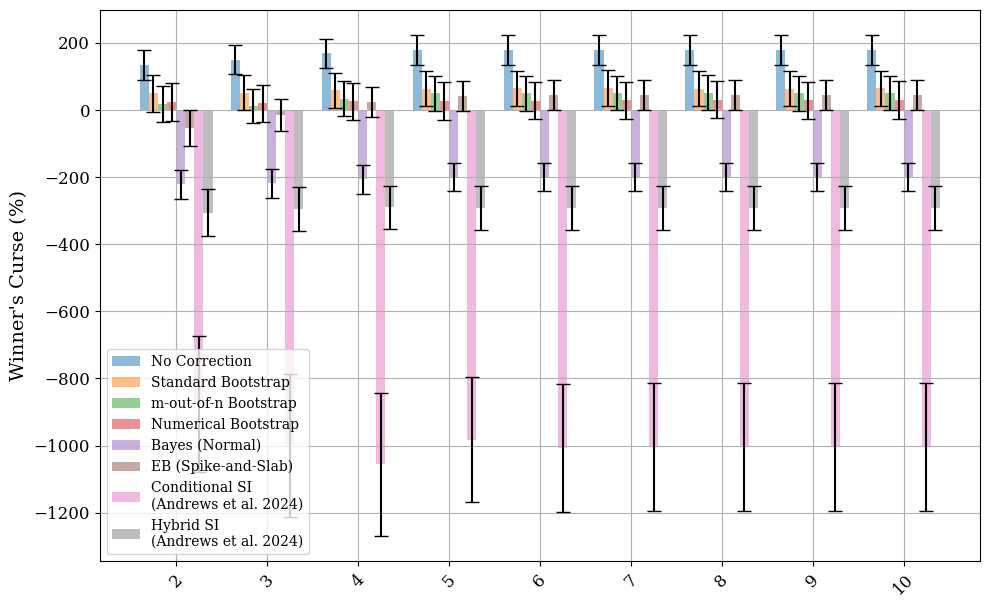

2       3        4       5   \
No Correction                         Mean    133.99  150.21   168.62  178.08   
                                      Median  135.30  150.91   167.97  182.98   
                                      S.E.     23.20   22.56    22.65   22.69   
Standard Bootstrap                    Mean     49.46   51.27    59.12   64.23   
                                      Median   33.40   47.50    59.03   64.15   
                                      S.E.     27.53   26.63    26.71   26.58   
m-out-of-n Bootstrap                  Mean     17.12   12.98    34.15   49.42   
                                      Median    4.88    2.66    34.82   45.57   
                                      S.E.     27.15   26.05    26.26   26.33   
Numerical Bootstrap                   Mean     23.08   20.66    26.52   27.47   
                                      Median   17.53   12.31    32.12   31.52   
                                      S.E.     28.92   28.04    28.24   28.41   
Bayes (Normal)                        Mean   -221.76 -218.50  -206.88 -200.04   
                                      Median -205.20 -198.04  -182.19 -176.27   
                                      S.E.     22.60   21.79    21.79   21.76   
EB (Spike-and-Slab)                   Mean    -53.67  -14.54    24.89   42.62   
                                      Median  -27.60  -17.09    29.09   47.42   
                                      S.E.     27.98   23.81    22.69   22.79   
Conditional SI\n(Andrews et al. 2024) Mean   -875.60 -999.68 -1056.45 -982.69   
                                      Median -589.36 -710.98  -704.90 -702.97   
                                      S.E.    103.30  108.80   109.07   95.26   
Hybrid SI\n(Andrews et al. 2024)      Mean   -305.54 -294.48  -290.30 -291.31   
                                      Median -311.89 -287.95  -264.55 -251.82   
                                      S.E.     35.15   33.12    33.29   33.21   

                                                   6        7        8   \
No Correction                         Mean     179.07   179.07   179.07   
                                      Median   182.84   182.84   182.84   
                                      S.E.      22.69    22.68    22.68   
Standard Bootstrap                    Mean      64.99    65.68    63.60   
                                      Median    61.41    69.03    58.68   
                                      S.E.      26.59    26.67    26.60   
m-out-of-n Bootstrap                  Mean      49.57    51.11    51.99   
                                      Median    49.51    48.53    46.99   
                                      S.E.      26.31    26.40    26.17   
Numerical Bootstrap                   Mean      28.44    28.78    31.02   
                                      Median    33.94    34.18    25.94   
                                      S.E.      28.07    28.27    28.20   
Bayes (Normal)                        Mean    -199.47  -199.48  -199.48   
                                      Median  -175.15  -175.15  -175.15   
                                      S.E.      21.73    21.73    21.73   
EB (Spike-and-Slab)                   Mean      44.25    44.25    44.25   
                                      Median    49.05    49.05    49.05   
                                      S.E.      22.75    22.75    22.75   
Conditional SI\n(Andrews et al. 2024) Mean   -1006.88 -1004.28 -1004.28   
                                      Median  -713.87  -713.87  -713.87   
                                      S.E.      97.30    96.93    96.93   
Hybrid SI\n(Andrews et al. 2024)      Mean    -291.53  -291.54  -291.42   
                                      Median  -259.23  -258.17  -259.43   
                                      S.E.      33.17    33.16    33.15   

                                                   9        10  
No Correction                         Mean     179.07   179.07  
                  

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = max_depth_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for max_depth in max_depth_list:
    data[max_depth] = {}

    data[max_depth]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[max_depth][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for max_depth in max_depth_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[max_depth][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=max_depth_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(max_depth_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in max_depth_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in max_depth_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(max_depth_list)), 
    labels=max_depth_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)